# Ratio-CATE Learner Benchmark

Evaluation of meta-learners for ratio-based CATE estimation:
$$\tau(x) = \frac{E[Y|W=1,X]}{E[Y|W=0,X]}$$

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import ALL_DATASETS, RCT_DATASETS, OBS_DATASETS, CONVERSION_RATES
from learner import ALL_LEARNER
from benchmark import run_benchmark
from visualization import plot_heatmap, insignificant_datasets, plot_best_per_group, plot_dots_with_lines
from tables import make_metric_table


## Configuration

In [2]:
# Datasets to evaluate
DATASETS = ALL_DATASETS
# Learners to evaluate
LEARNER = list(ALL_LEARNER.keys())

# Number of runs per combination
N_RUNS = 50

# Base seed (each run uses BASE_SEED + run_idx)
BASE_SEED = 42


RESULTS_CSV = 'benchmark_results.csv'

In [3]:
print(f"Datasets: {DATASETS}")
print(f"Learners: {LEARNER}")
print(f"Runs per combination: {N_RUNS}")


Datasets: ['H(Conv)', 'Twins', 'Criteo', 'Lenta', 'H(Vis)', 'MegaFon', 'X5', 'Cattaneo', 'NHEFS', 'JTPA', 'RHC']
Learners: ['S', 'T', 'X', 'R', 'DR', 'Q', 'Q-Simple', 'DR-S', 'DR-T', 'DR-Q', 'DR-Q-Simple', 'DR-S log', 'DR-T log', 'DR-Q log', 'DR-Q-Simple log']
Runs per combination: 50


## Run Benchmark

In [4]:
df_results = run_benchmark(
    datasets=DATASETS,
    learners=LEARNER,
    n_runs=N_RUNS,
    base_seed=BASE_SEED,
    results_csv=RESULTS_CSV,
)


Loaded 43650 existing results from benchmark_results.csv
Skipping 43650 already-completed combinations


Datasets: 100%|██████████| 11/11 [00:48<00:00,  4.40s/it]


In [ ]:

#Especially smaller datasets suffer from larger variance across the seeds. 
#This can be seen in many gray cells in the heatmap, highlighting
#missing statistical significance. We identify such datasets and run more seeds for them

ADDITIONAL_RUNS_PER_TOPUP = 50
MAX_TOPUPS = 5            # safety cap; with 50-seed batches that's +250 max
MIN_GREY_CELLS = 3        # top up datasets with at least this many grey cells

for round_idx in range(MAX_TOPUPS):
    pending = insignificant_datasets(
        df_results, metric='qini_ratio',
        baseline='S',
        learners=LEARNER,
        datasets=DATASETS,
        min_grey_cells=MIN_GREY_CELLS,
    )
    if not pending:
        print(f"All datasets significant. Done after {round_idx} top-up round(s).")
        break

    # How many seeds does each pending dataset already have?
    have = (
        df_results[df_results['dataset'].isin(pending)]
        .groupby('dataset')['seed'].nunique()
        .to_dict()
    )
    print(f"\n=== Top-up round {round_idx + 1}: "
        f"{len(pending)} dataset(s) still have grey cells ===")
    for d in pending:
        print(f"  {d}: {have.get(d, 0)} seeds → +{ADDITIONAL_RUNS_PER_TOPUP}")

    df_results = run_benchmark(
        datasets=pending,
        learners=LEARNER,
        n_runs=max(have.values()) + ADDITIONAL_RUNS_PER_TOPUP,
        base_seed=BASE_SEED,
        results_csv='benchmark_results.csv',
    )
else:
    print(f"\nReached MAX_TOPUPS={MAX_TOPUPS}; some datasets may still be grey.")

## Export Results

In [ ]:
# Save raw results
df_results.to_csv(RESULTS_CSV, index=False)

print("Results saved")

## Visualizations

In [5]:


LEARNER_ORDER = list(ALL_LEARNER.keys())

plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

print(f"df_results rows: {len(df_results)}")
print(f"learners present: {sorted(df_results['learner'].unique())}")
print(f"datasets present: {sorted(df_results['dataset'].unique())}")


df_results rows: 43650
learners present: ['DR', 'DR-Q', 'DR-Q log', 'DR-Q-Simple', 'DR-Q-Simple log', 'DR-S', 'DR-S log', 'DR-T', 'DR-T log', 'Q', 'Q-Simple', 'R', 'S', 'T', 'X']
datasets present: ['Cattaneo', 'Criteo', 'H(Conv)', 'H(Vis)', 'JTPA', 'Lenta', 'MegaFon', 'NHEFS', 'RHC', 'Twins', 'X5']


### Heatmaps: Qini (ratio CATE)

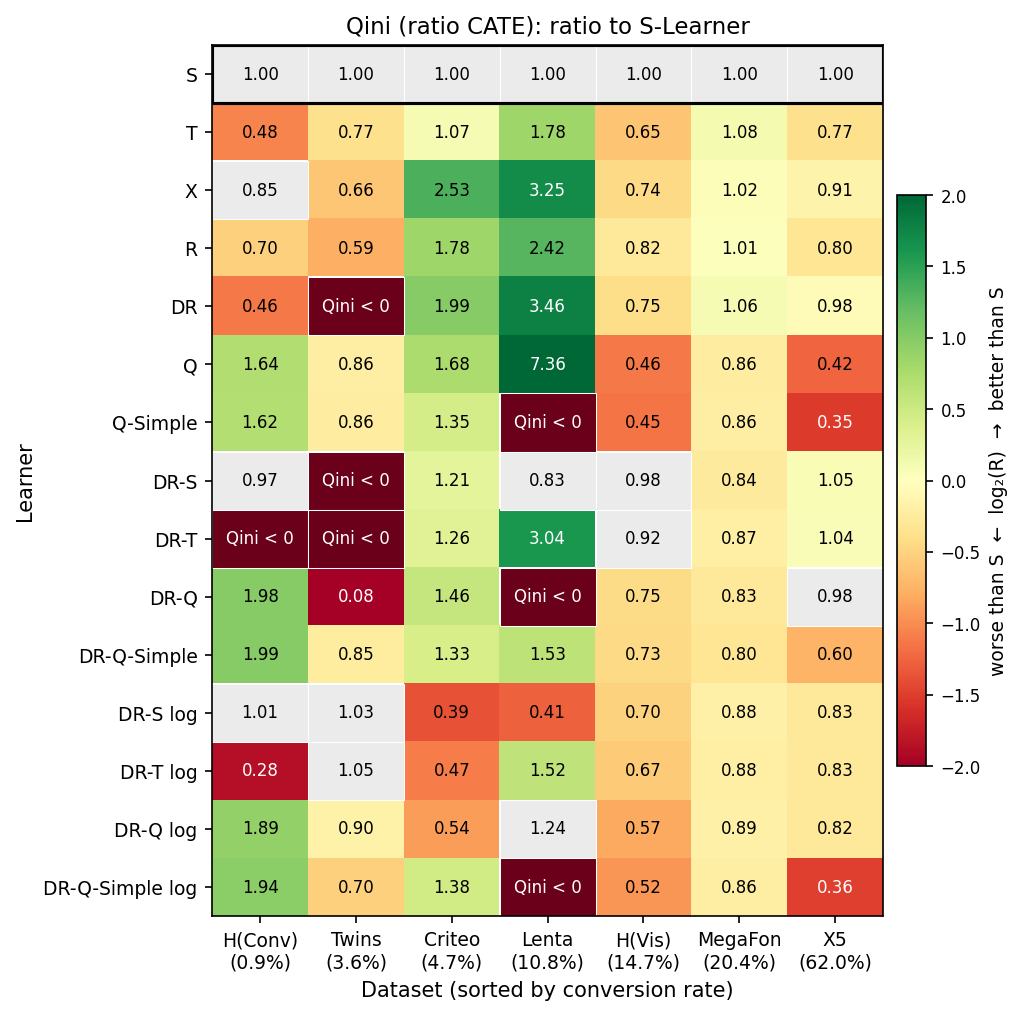

(<Figure size 1042.5x1035 with 2 Axes>,
 dataset           H(Conv)     Twins    Criteo     Lenta    H(Vis)   MegaFon  \
 learner                                                                       
 S                1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
 T                0.481255  0.770495  1.065953  1.776192  0.653258  1.075407   
 X                0.848763  0.660214  2.528271  3.249888  0.736489  1.024517   
 R                0.698334  0.587472  1.778016  2.417411  0.818271  1.013671   
 DR               0.463394 -0.496895  1.992586  3.463001  0.749747  1.061690   
 Q                1.644533  0.861618  1.676239  7.362088  0.462334  0.858768   
 Q-Simple         1.622539  0.858907  1.348101 -0.113034  0.448748  0.864310   
 DR-S             0.966701 -0.204709  1.210926  0.834878  0.976356  0.838977   
 DR-T            -0.001419 -0.117161  1.255186  3.042151  0.924338  0.868828   
 DR-Q             1.984266  0.081209  1.461104 -3.200555  0.746238  0.831171   


In [6]:
# Heatmap: Qini ratio CATE on RCT datasets
plot_heatmap(
    df_results, metric='qini_ratio',
    datasets=RCT_DATASETS,
    learner_order= LEARNER_ORDER,
    conv_rates=CONVERSION_RATES,
    savepath='fig_heatmap_qini_ratio_rct.png',
)


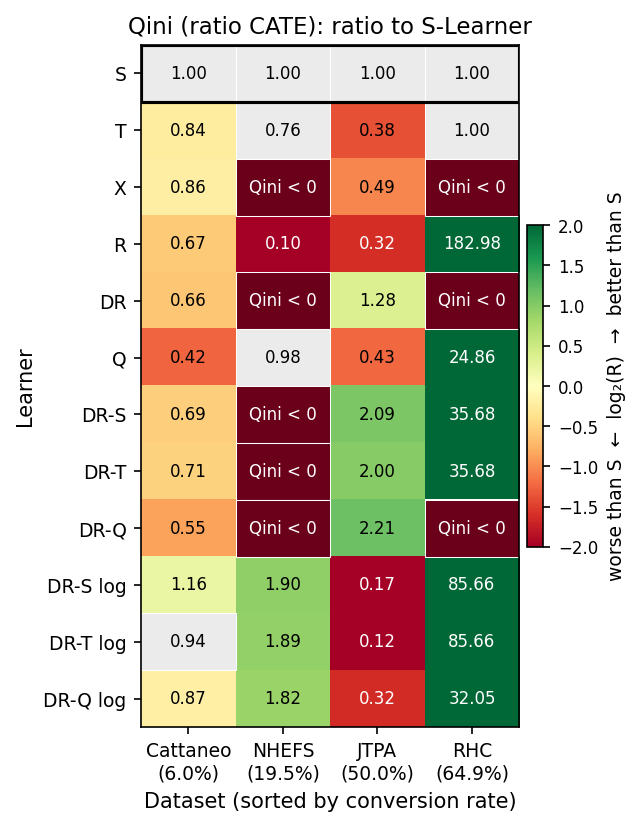

(<Figure size 660x846 with 2 Axes>,
 dataset   Cattaneo     NHEFS      JTPA         RHC
 learner                                           
 S         1.000000  1.000000  1.000000    1.000000
 T         0.841604  0.757702  0.382364    1.000000
 X         0.864117 -0.755942  0.487642 -168.170044
 R         0.673998  0.096533  0.324911  182.981297
 DR        0.662218 -0.215007  1.282192  -32.645650
 Q         0.423391  0.982435  0.426235   24.855696
 DR-S      0.686949 -0.380677  2.088387   35.679921
 DR-T      0.706021 -0.363039  1.997520   35.679921
 DR-Q      0.548594 -0.833066  2.210839  -39.519111
 DR-S log  1.158513  1.903645  0.174542   85.661907
 DR-T log  0.944872  1.892886  0.119773   85.661907
 DR-Q log  0.870882  1.818461  0.323397   32.054816)

In [7]:
# Heatmap: Qini ratio CATE on observational datasets
plot_heatmap(
    df_results, metric='qini_ratio',
    datasets=OBS_DATASETS,
    learner_order=LEARNER_ORDER,
    conv_rates=CONVERSION_RATES,
    savepath='fig_heatmap_qini_ratio_obs.png',
)


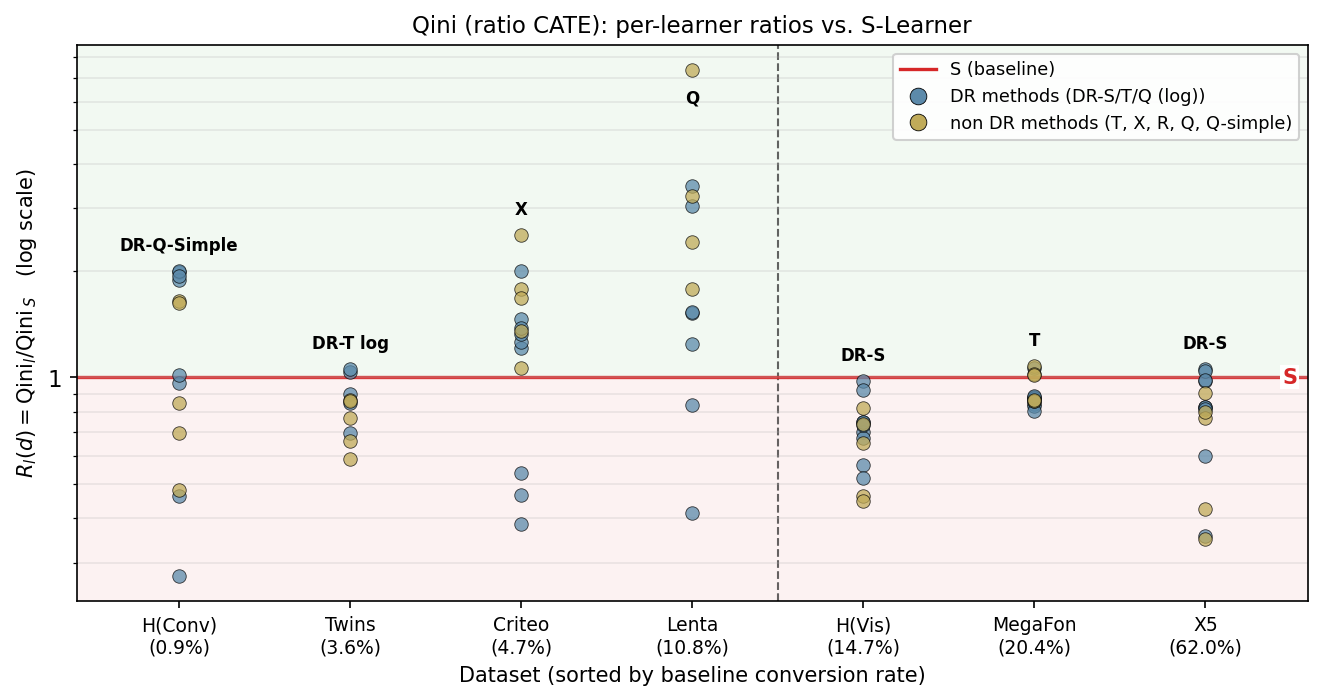

In [37]:

groups = {
    'DR methods (DR-S/T/Q (log))':           ['DR', 'DR-S', 'DR-S log', 'DR-T', 'DR-T log', 'DR-Q', 'DR-Q log', 'DR-Q-Simple', 'DR-Q-Simple log'],
    'non DR methods (T, X, R, Q, Q-simple)':             ['T',  'X', 'R', 'Q', 'Q-Simple']
}

fig, ratio = plot_dots_with_lines(
    df_results, 'qini_ratio', RCT_DATASETS,
    conv_rates=CONVERSION_RATES,
    groups=groups,
    regime_split_after=3,                  # split between 4th and 5th column
    savepath='fig_rct_dots.png',
)

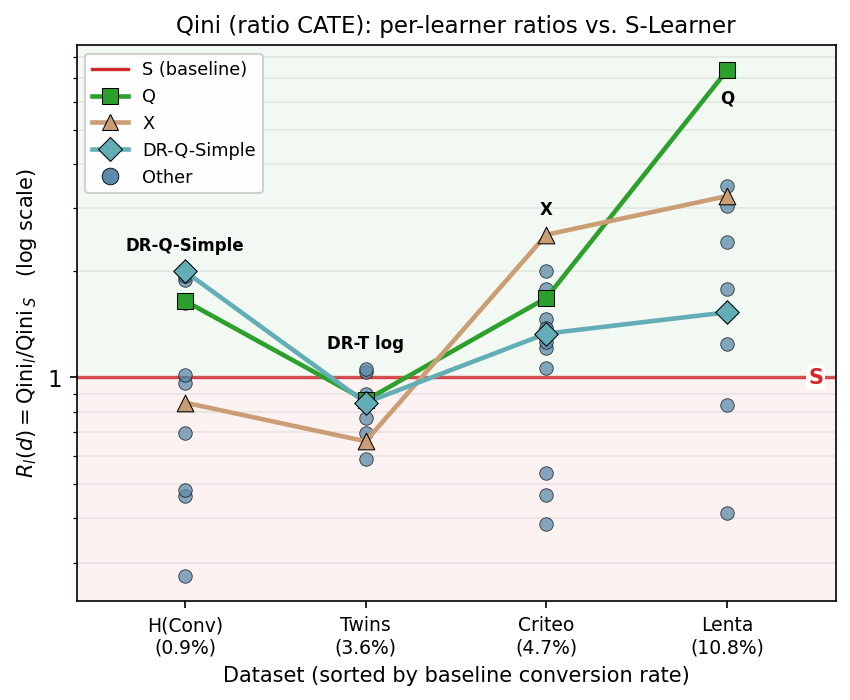

In [38]:

groups = {
    'Other':           ['Q-Simple','DR', 'DR-S', 'DR-S log', 'DR-T', 'DR-T log', 'DR-Q', 'DR-Q log',  'DR-Q-Simple log', 'T',  'X', 'R']
}

fig, ratio = plot_dots_with_lines(
    df_results, 'qini_ratio', ['H(Conv)', 'Twins', 'Criteo', 'Lenta'],
    conv_rates=CONVERSION_RATES,
    groups=groups,
    extras=['Q', 'X', 'DR-Q-Simple'],                          # featured learner as line
    #secondary=[],
    #regime_split_after=3,                  # split between 4th and 5th column
    savepath='fig_rct_learners.png',
)

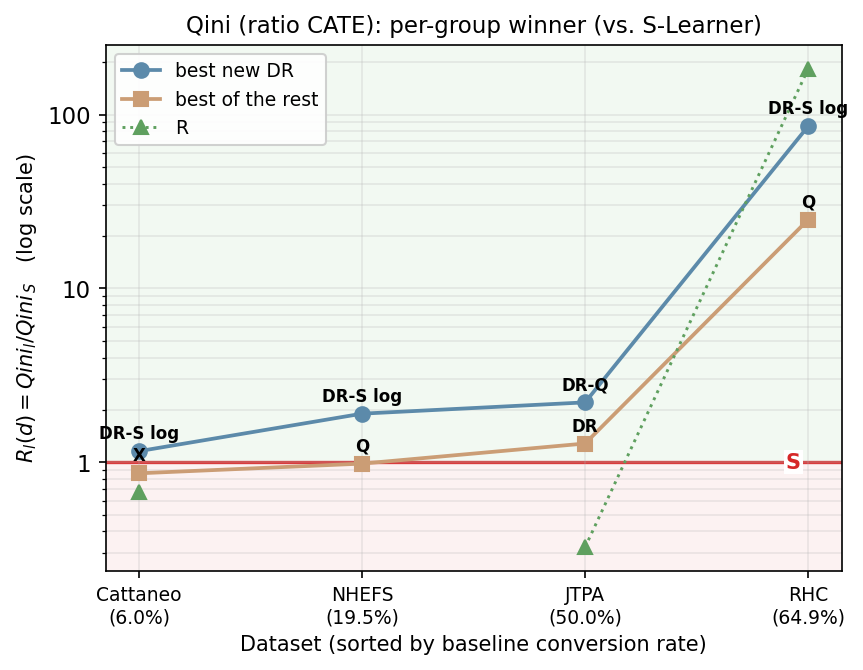

In [39]:
groups = {
    'best new DR':       ['DR-S', 'DR-S log', 'DR-T', 'DR-T log',
                        'DR-Q', 'DR-Q log', 'DR-Q-Simple', 'DR-Q-Simple log'],
    'best of the rest':  ['T', 'Q', 'Q-Simple', 'X', 'DR'],   # R excluded
}

fig, best_ratio, best_winner = plot_best_per_group(
    df_results, 'qini_ratio', OBS_DATASETS,
    conv_rates=CONVERSION_RATES,
    groups=groups,
    extras=['R'],                            # R as dotted overlay
    savepath='fig_obs_new_vs_rest.png',
)

### Heatmaps: CalError (ratio CATE)

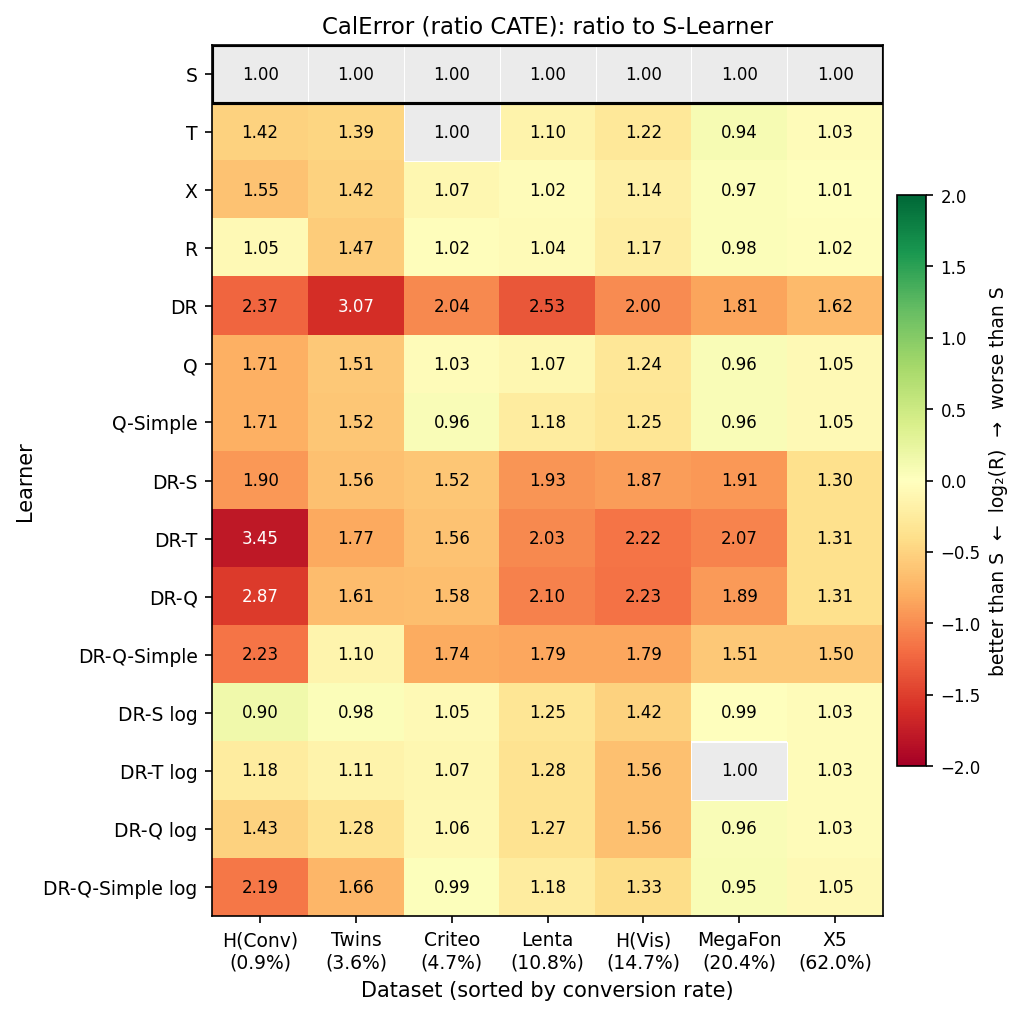

(<Figure size 1042.5x1035 with 2 Axes>,
 dataset           H(Conv)     Twins    Criteo     Lenta    H(Vis)   MegaFon  \
 learner                                                                       
 S                1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
 T                1.415140  1.393397  0.998329  1.104455  1.217339  0.939172   
 X                1.549913  1.420210  1.071625  1.022469  1.140831  0.972382   
 R                1.049887  1.471196  1.018632  1.035002  1.169063  0.976452   
 DR               2.373872  3.067572  2.035566  2.533532  2.000664  1.811189   
 Q                1.714758  1.509090  1.027047  1.071378  1.236576  0.960654   
 Q-Simple         1.714025  1.520317  0.961533  1.180090  1.251374  0.963629   
 DR-S             1.901537  1.559138  1.522401  1.929661  1.867882  1.913574   
 DR-T             3.450550  1.774890  1.558987  2.025163  2.220517  2.069131   
 DR-Q             2.874211  1.609558  1.581796  2.103789  2.229306  1.892171   


In [30]:
# Heatmap: CalError ratio CATE on RCT datasets
plot_heatmap(
    df_results, metric='cal_error_ratio',
    datasets=RCT_DATASETS,
    learner_order=LEARNER_ORDER,
    conv_rates=CONVERSION_RATES,
    savepath='fig_heatmap_cal_ratio_rct.png',
)


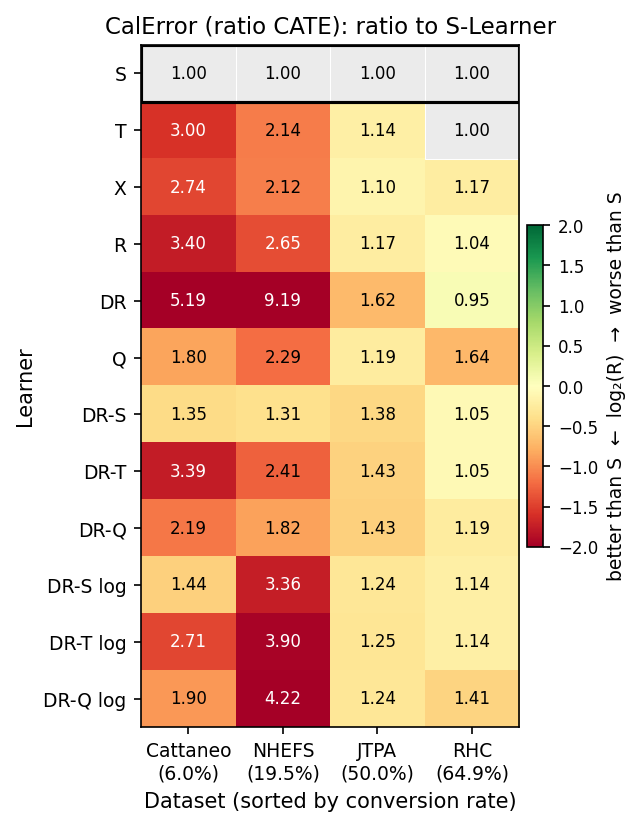

(<Figure size 660x846 with 2 Axes>,
 dataset   Cattaneo     NHEFS      JTPA       RHC
 learner                                         
 S         1.000000  1.000000  1.000000  1.000000
 T         3.003951  2.137071  1.142713  1.000000
 X         2.737313  2.121919  1.099502  1.168625
 R         3.397435  2.648532  1.167333  1.039960
 DR        5.191815  9.190777  1.622657  0.950528
 Q         1.795515  2.293673  1.188448  1.642253
 DR-S      1.353599  1.308717  1.377080  1.046736
 DR-T      3.392806  2.409476  1.428347  1.046736
 DR-Q      2.190195  1.816342  1.431656  1.187667
 DR-S log  1.436220  3.356586  1.236310  1.142572
 DR-T log  2.714119  3.897085  1.247706  1.142572
 DR-Q log  1.898816  4.217264  1.241486  1.412905)

In [31]:
# Heatmap: CalError ratio CATE on observational datasets
plot_heatmap(
    df_results, metric='cal_error_ratio',
    datasets=OBS_DATASETS,
    learner_order=LEARNER_ORDER,
    conv_rates=CONVERSION_RATES,
    savepath='fig_heatmap_cal_ratio_obs.png',
)


## LaTeX Tables

In [32]:
# LaTeX tables: per-dataset Qini and CalError, ratio and difference scales

QINI_RATIO_CAPTION_TPL = (
    'Qini coefficient (ratio CATE) on {kind} datasets (mean over seeds; '
    r'SE in parentheses). Best per column in \textbf{bold}.'
    'Bottom row: mean across all learners per dataset.'
)
QINI_DIFF_CAPTION_TPL = (
    'Qini coefficient (difference CATE, cumulative-gain formulation) on {kind} datasets '
    '(mean over seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}.'
)
CAL_RATIO_CAPTION_TPL = (
    'Multiplicative calibration error (ratio CATE) on {kind} datasets '
    '(mean over seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}.'
)
CAL_DIFF_CAPTION_TPL = (
    'Calibration error (difference CATE) on {kind} datasets '
    '(mean over seeds; SE in parentheses). '
    r'Best per column in \textbf{bold}.'
)


def emit(metric_key, datasets, kind, label, caption_tpl):
    print(make_metric_table(
        df_results, metric=metric_key, datasets=datasets,
        caption=caption_tpl.replace('{kind}', kind), label=label,
    ))
    print('\n\n')


# Qini ratio
emit('qini_ratio', RCT_DATASETS,      'RCT',           'tab:qini-ratio-rct', QINI_RATIO_CAPTION_TPL)
emit('qini_ratio', OBS_DATASETS, 'observational', 'tab:qini-ratio-obs', QINI_RATIO_CAPTION_TPL)

# CalError ratio
emit('cal_error_ratio', RCT_DATASETS,      'RCT',           'tab:cal-ratio-rct', CAL_RATIO_CAPTION_TPL)
emit('cal_error_ratio', OBS_DATASETS, 'observational', 'tab:cal-ratio-obs', CAL_RATIO_CAPTION_TPL)




\begin{table}[H]
\centering
\footnotesize
\caption{Qini coefficient (ratio CATE) on RCT datasets (mean over seeds; SE in parentheses). Best per column in \textbf{bold}.Bottom row: mean across all learners per dataset.}
\label{tab:qini-ratio-rct}
\setlength{\tabcolsep}{3pt}
\begin{tabular}{l | rrrrrrr}
\hline
Learner & H(Conv) & Twins & Criteo & Lenta & H(Vis) & MegaFon & X5 \\
\hline
S
 & 0.286 & 0.087 & 0.337 & 0.012 & \textbf{0.437} & 1.436 & 0.073 \\
 & \scriptsize(0.024) & \scriptsize(0.003) & \scriptsize(0.003) & \scriptsize(0.001) & \scriptsize(0.025) & \scriptsize(0.007) & \scriptsize(0.001) \\[2pt]
T
 & 0.138 & 0.067 & 0.359 & 0.021 & 0.285 & \textbf{1.544} & 0.056 \\
 & \scriptsize(0.018) & \scriptsize(0.003) & \scriptsize(0.003) & \scriptsize(0.001) & \scriptsize(0.018) & \scriptsize(0.007) & \scriptsize(0.001) \\[2pt]
X
 & 0.243 & 0.057 & \textbf{0.852} & 0.039 & 0.322 & 1.471 & 0.066 \\
 & \scriptsize(0.020) & \scriptsize(0.003) & \scriptsize(0.006) & \scriptsize(0.002) & \